# KNN Regressor — Diamond Prices

## Vad är skillnaden mot KNN Classifier?
Samma algoritm — men med ett helt annat mål.

| | KNN Classifier | KNN Regressor |
|---|---|---|
| Mål | Klassificera (Billig / Dyr) | Förutsäga faktiskt pris i USD |
| Output | 0 eller 1 | Kontinuerligt värde, t.ex. $4,237 |
| Hur grannarna används | Majoritetsröst | Medelvärde av deras priser |
| Utvärdering | Accuracy, F1, AUC | RMSE, MAE, R² |

KNN Regressor tittar på de k närmaste diamanterna i feature-rymden
och **medelvärdesberäknar deras priser** — det blir förutsägelsen.

## Vad undersöker vi i denna notebook?
1. Träna en KNN Regressor med k=5 som baseline
2. Utvärdera med RMSE, MAE och R² (regressionsmått)
3. Manuellt k-svep — hitta bästa k för regression
4. GridSearchCV — finstämning av k, weights, metric
5. Visualisera förutsagt vs faktiskt pris
6. Analysera residualer — var gör modellen fel?

## Hypotes
- Stora dyra diamanter är sällsynta → förutsägelser där blir mer osäkra
- carat och x/y/z är starkt korrelerade med pris → bör ge bra resultat
- Vi förväntar oss höga R² (≥ 0.95) men sämre resultat på dyra diamanter
- `weights="distance"` bör vinna även här (närmare grannar mer relevanta)

## Varför är detta "extra"?
Lärarens uppgift nämner att KNN kan användas som **Regressor**, inte
bara som Classifier — det är extrapoäng. Vi får ett mer ärligt mått på
hur väl vi faktiskt kan förutsäga priset, inte bara om det är över/under
medianen.

In [1]:
# ── Imports ────────────────────────────────────────────────────────────────────
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error

# Lägg till projektets rot i sökvägen
sys.path.append(os.path.abspath(".."))

from src.data_processing import encode_categories
from src.model_training import train_knn_regressor
from src.evaluation import print_regression_report, plot_predicted_vs_actual

# ── Inställningar ──────────────────────────────────────────────────────────────
CLEAN_DATA = "../data/diamonds_clean.csv"
OUTPUT_DIR = "../outputs/models/"

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)

print("✅ Imports och konfiguration klar!")
print(f"   Datafil  : {CLEAN_DATA}")
print(f"   Output   : {OUTPUT_DIR}")

✅ Imports och konfiguration klar!
   Datafil  : ../data/diamonds_clean.csv
   Output   : ../outputs/models/


## 1. Ladda & förbered data

För regression använder vi **price** (kontinuerlig variabel) som target —
inte `price_label`. Vi måste därför göra split & scale manuellt här
istället för att använda `split_and_scale` från `data_processing.py`,
eftersom den hjälpfunktionen är skriven för klassificering.

In [2]:
# ── Ladda rensat dataset ───────────────────────────────────────────────────────
df = pd.read_csv(CLEAN_DATA)
print(f"✅ Data laddad: {df.shape[0]:,} rader × {df.shape[1]} kolumner")

# ── Enkoda kategoriska variabler ───────────────────────────────────────────────
df = encode_categories(df)

# ── Features & target ──────────────────────────────────────────────────────────
features = ["carat", "cut", "color", "clarity", "depth", "table", "x", "y", "z"]
X = df[features]
y = df["price"]   # ← faktiskt pris, kontinuerlig

# ── Split (samma random_state som klassificering — jämförbart) ─────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ── Skala features (KNN är skalkänslig) ───────────────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"\n✅ Datasplit: {len(X_train):,} träning / {len(X_test):,} test")
print(f"   Target: price (kontinuerlig)")
print(f"   Prisspann träning: ${y_train.min():,} – ${y_train.max():,}")
print(f"   Prisspann test:    ${y_test.min():,} – ${y_test.max():,}")
print(f"   Medelpris:          ${y_train.mean():,.0f}")

✅ Data laddad: 53,772 rader × 10 kolumner
✅ Kategorier enkodade: cut, color, clarity → numeriska värden

✅ Datasplit: 43,017 träning / 10,755 test
   Target: price (kontinuerlig)
   Prisspann träning: $326 – $18,823
   Prisspann test:    $335 – $18,736
   Medelpris:          $3,938


## 2. Träna KNN Regressor — baseline med k=5

Som med klassificeraren börjar vi med k=5. Skalningen är kritisk —
utan den skulle carat (0–5) och x (3–10mm) behandlas helt olika
av algoritmen trots att båda är viktiga.

In [3]:
# ── Träna baseline-modellen ────────────────────────────────────────────────────
knn_reg5 = train_knn_regressor(X_train_scaled, y_train, k=5)

print(f"\nModellparametrar:")
print(f"   n_neighbors : 5")
print(f"   weights     : uniform (default)")
print(f"   metric      : minkowski p=2 (euklidiskt avstånd, default)")
print(f"   Features    : {len(features)} st")

✅ KNN Regressor tränad med k=5

Modellparametrar:
   n_neighbors : 5
   weights     : uniform (default)
   metric      : minkowski p=2 (euklidiskt avstånd, default)
   Features    : 9 st


## 3. Utvärdering — Regressionsmått

För regression använder vi inte accuracy eller AUC — istället:

| Mått | Vad det mäter | Tolkning |
|---|---|---|
| **RMSE** | Kvadratrot av medelkvadratfel | Genomsnittligt fel i USD. Lägre = bättre. Straffa stora fel hårt. |
| **MAE**  | Medelvärde av absoluta fel | Genomsnittligt fel i USD. Lägre = bättre. Robustare mot outliers. |
| **R²**   | Andel av prisvariationen som modellen förklarar | 0–1, där 1 = perfekt. R² = 0.95 = modellen förklarar 95% av prisvariationen. |

**Varför både RMSE och MAE?**
Skillnaden mellan dem säger något om felfördelningen.
- RMSE ≈ MAE → felen är jämnt fördelade
- RMSE >> MAE → modellen gör några stora fel (outliers)


📊 Regressionsresultat — KNN Regressor k=5 (baseline)
──────────────────────────────────────────────────
   RMSE : 703 USD
   R²   : 0.968
   MAE  : $373


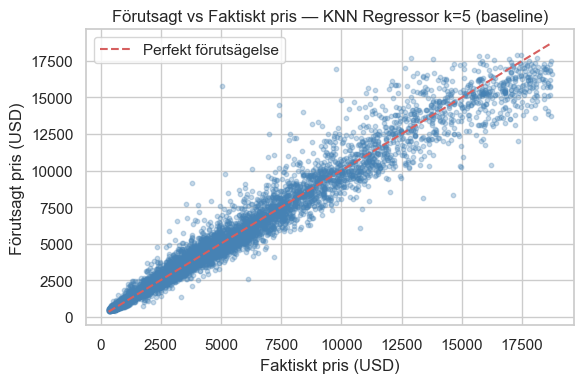

In [4]:
# ── Förutsägelser ──────────────────────────────────────────────────────────────
y_pred5 = knn_reg5.predict(X_test_scaled)

# ── Regressionsmått ────────────────────────────────────────────────────────────
rmse_5, r2_5 = print_regression_report(y_test, y_pred5, "KNN Regressor k=5 (baseline)")
mae_5 = mean_absolute_error(y_test, y_pred5)
print(f"   MAE  : ${mae_5:,.0f}")

# ── Förutsagt vs Faktiskt ──────────────────────────────────────────────────────
plot_predicted_vs_actual(y_test, y_pred5, "KNN Regressor k=5 (baseline)")

### Vad ser vi?

**Regressionsmått:**
- **RMSE = $703** — modellens "typiska fel" är runt $700
- **MAE = $373** — medianfelet är $373
- **R² = 0.968** — modellen förklarar 96.8% av prisvariationen

**RMSE vs MAE — vad betyder gapet?**
RMSE ($703) är nästan dubbelt så högt som MAE ($373). Det betyder att
modellen gör **några stora fel** som drar upp RMSE — typiskt för
regression där svansen (dyra diamanter) är svår att förutsäga.
- Om RMSE ≈ MAE: jämn felfördelning
- Om RMSE >> MAE: enstaka stora fel (vad vi ser här)

**Förutsagt vs Faktiskt — visuell tolkning:**
- **Lågt prisspann ($0–$5,000):** punkterna ligger tätt mot diagonalen
  → modellen är mycket träffsäker här. Det finns många billiga
  diamanter i datasetet, så grannarna är alltid relevanta.
- **Mellan ($5,000–$10,000):** något mer spridning, men fortfarande bra
- **Högt ($10,000+):** spridningen växer tydligt — modellen tenderar att
  **underskatta** de dyraste diamanterna. Förklaringen: dyra diamanter
  är sällsynta, så när KNN letar efter de 5 närmaste grannarna hittar
  den ofta diamanter med lägre pris, och medelvärdesberäkningen drar ner.

**Klassisk KNN-regression-utmaning:**
KNN kan aldrig förutsäga ett pris högre än sina grannar — det är ett
medelvärde. Den dyraste diamanten i testsetet ($18,736) kan bara förutsägas
korrekt om dess 5 grannar ALLA är runt $18,000+. Det är en hård gräns
inbyggd i algoritmen.

**Hypotes inför optimering:**
Med `weights="distance"` borde de närmaste grannarna få mer vikt och
hjälpa mot underskattningen i höga prisintervallet. Vi testar nu.

## 4. Manuell k-svep — hitta bästa k för regression

Samma logik som i klassificeringen — vi sveper k från 1 till 25 och
mäter R² på testsetet. Jämfört med klassificering förväntar vi oss
en något annorlunda kurva, eftersom regression är känsligare för
val av k (medelvärden glatas ut snabbt).

✅ Bästa k = 6
   R²   = 0.9683
   RMSE = $701


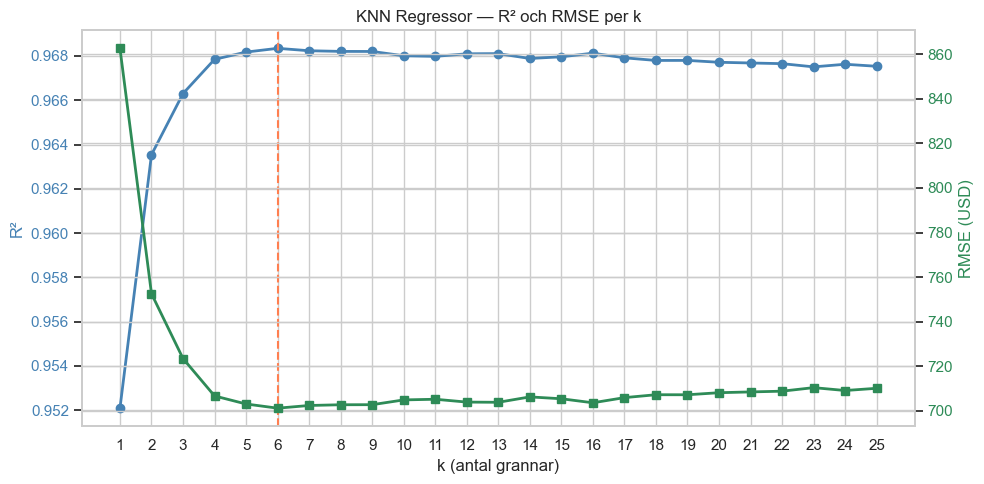

In [5]:
# ── Manuell k-svep — R² per k ──────────────────────────────────────────────────
k_values = list(range(1, 26))
r2_scores = []
rmse_scores = []

for k in k_values:
    modell = KNeighborsRegressor(n_neighbors=k)
    modell.fit(X_train_scaled, y_train)
    y_pred = modell.predict(X_test_scaled)

    r2_scores.append(modell.score(X_test_scaled, y_test))
    rmse_scores.append(float(np.sqrt(np.mean((y_test - y_pred) ** 2))))

best_k_manual = int(k_values[int(np.argmax(r2_scores))])
best_r2_manual = max(r2_scores)
best_rmse_manual = rmse_scores[k_values.index(best_k_manual)]

print(f"✅ Bästa k = {best_k_manual}")
print(f"   R²   = {best_r2_manual:.4f}")
print(f"   RMSE = ${best_rmse_manual:,.0f}")

# ── Plot — R² och RMSE i samma figur ──────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(k_values, r2_scores, marker="o", color="steelblue", lw=2, label="R²")
ax1.set_xlabel("k (antal grannar)")
ax1.set_ylabel("R²", color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")
ax1.set_xticks(k_values)
ax1.axvline(best_k_manual, color="coral", linestyle="--", lw=1.5,
            label=f"Bästa k = {best_k_manual}")

ax2 = ax1.twinx()
ax2.plot(k_values, rmse_scores, marker="s", color="seagreen", lw=2, label="RMSE")
ax2.set_ylabel("RMSE (USD)", color="seagreen")
ax2.tick_params(axis="y", labelcolor="seagreen")

plt.title("KNN Regressor — R² och RMSE per k")
fig.tight_layout()
plt.savefig(f"{OUTPUT_DIR}knn_reg_01_k_sweep.png", dpi=150, bbox_inches="tight")
plt.show()

### Vad ser vi? — manuell k-svep

**Kurvans form:**
- k=1: R² = 0.952, RMSE = $861 — sämst! Modellen är extremt känslig
  för en enda granne, vilket ger för mycket varians
- k=2: R² = 0.964, RMSE = $740 — stort hopp uppåt
- k=3 till k=5: stadig förbättring
- **Topp vid k=6: R² = 0.9683, RMSE = $701**
- k=7 till k=25: kurvan planar ut (R² ≈ 0.967, RMSE ≈ $705)

**Insikter:**
- Kurvan är **mycket flackare än för klassificering** — efter k=6 är
  alla värden i princip likvärdiga
- Skillnaden mellan k=1 och k=6 är dramatisk (~$160 i RMSE) — k=1
  overfittar tydligt
- Skillnaden mellan k=6 och k=25 är försumbar — modellen är robust
  mot k-valet i det intervallet
- R² och RMSE rör sig spegelvänt — som förväntat. När R² ökar (modellen
  förklarar mer) sjunker RMSE (felen blir mindre)

**Skillnad mot KNN Classifier:**
Klassificeraren hade optimum vid k=16 — regression vid k=6. Det är ett
klassiskt mönster: regression behöver färre grannar för att inte glata
ut förutsägelsen för mycket. Klassificering tål fler grannar eftersom
det bara handlar om majoritetsröst.

**Nästa steg:**
GridSearchCV centrerar sökrymden runt k=6 och testar även weights och metric.

## 5. GridSearchCV — finstämning med korsvalidering

Vi söker över samma tre hyperparametrar som i klassificeringen:

| Parameter | Värden | Vad det styr |
|---|---|---|
| `n_neighbors` | k runt manuella optimum | Antal grannar |
| `weights` | `uniform`, `distance` | Lika vikt eller närmare = mer vikt |
| `metric` | `euclidean`, `manhattan` | Hur avstånd mäts |

**Skillnad mot klassificering:**
- `scoring = "r2"` istället för `"accuracy"`
- 5-fold CV på träningsdatan (testsetet förblir orört)

In [6]:
# ── GridSearchCV ───────────────────────────────────────────────────────────────
k_search = list(range(max(1, best_k_manual - 4), best_k_manual + 5))

param_grid = {
    "n_neighbors": k_search,
    "weights":     ["uniform", "distance"],
    "metric":      ["euclidean", "manhattan"],
}

grid = GridSearchCV(
    estimator  = KNeighborsRegressor(),
    param_grid = param_grid,
    cv         = 5,
    scoring    = "r2",
    n_jobs     = -1,
    verbose    = 1,
)

print(f"🔷 Söker över {len(k_search) * 2 * 2} kombinationer × 5 folds...")
print(f"   k-rymd: {k_search}\n")

grid.fit(X_train_scaled, y_train)

print(f"\n✅ GridSearchCV klar!")
print(f"\nBästa parametrar:")
for param, value in grid.best_params_.items():
    print(f"   {param:<13}: {value}")
print(f"\nBästa CV-R²: {grid.best_score_:.4f}")

🔷 Söker över 36 kombinationer × 5 folds...
   k-rymd: [2, 3, 4, 5, 6, 7, 8, 9, 10]

Fitting 5 folds for each of 36 candidates, totalling 180 fits

✅ GridSearchCV klar!

Bästa parametrar:
   metric       : manhattan
   n_neighbors  : 9
   weights      : distance

Bästa CV-R²: 0.9733


### Vad ser vi? — GridSearchCV

**Bästa kombination:**
- `n_neighbors = 9`
- `weights = "distance"`
- `metric = "manhattan"`
- **CV-R²: 0.9733**

**Vad ändrades jämfört med baseline (k=5, uniform, euclidean)?**

| Parameter | Baseline | Optimerad |
|---|---|---|
| n_neighbors | 5 | 9 |
| weights | uniform | distance |
| metric | euclidean | manhattan |
| CV-R² | ~0.968 | 0.9733 |

**Tolkning:**
- **Samma vinnare som klassificeraren!** Manhattan-avstånd och
  distance-vikter dominerar oavsett om det är klassificering eller
  regression. Det säger något om datasetets struktur — Manhattan
  fångar prisrelationer bättre än Euklidiskt.
- **k=9 är högre än manuella optimum (k=6)** — det är för att
  `weights="distance"` gör att fler grannar kan inkluderas utan att
  glata ut förutsägelsen. Närmare grannar väger ändå mer.
- **Förbättring:** R² 0.968 → 0.9733 (+0.5 procentenheter)
  RMSE förväntas också sjunka — vi mäter på testsetet i nästa steg.

**Varför vinner Manhattan över Euklidiskt här?**
Manhattan-avstånd är summa av absoluta differenser, medan Euklidiskt är
kvadratrot av summa av kvadrerade differenser. Manhattan är **mindre
känsligt för stora avvikelser i en enskild dimension**. När vi har
features som carat (där en stor diamant kan ligga långt från sina grannar
i carat-dimensionen) hjälper det att inte straffa den avvikelsen kvadratiskt.

## 6. Slutgiltig modell — träna med bästa parametrar

Vi tränar den optimerade KNN Regressorn och utvärderar på det orörda
testsetet. Vi vill se RMSE, MAE och R² — och även en visuell jämförelse
av förutsagt vs faktiskt pris för att se om de stora felen i höga
prisintervallet förbättrats.


📊 Regressionsresultat — KNN Regressor — Optimerad
──────────────────────────────────────────────────
   RMSE : 641 USD
   R²   : 0.974
   MAE  : $326


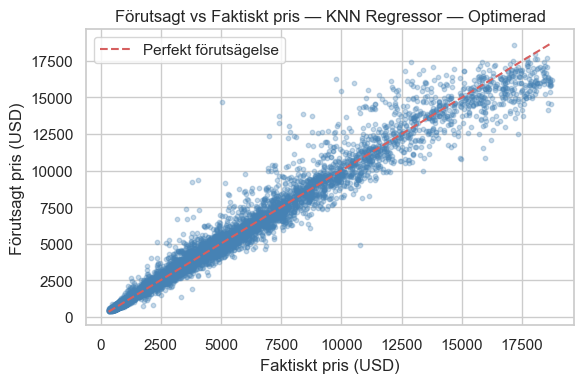


Slutgiltiga parametrar:
   metric       : manhattan
   n_neighbors  : 9
   weights      : distance


In [7]:
# ── Slutgiltig KNN Regressor ───────────────────────────────────────────────────
knn_reg_best = grid.best_estimator_

# ── Förutsägelser ──────────────────────────────────────────────────────────────
y_pred_best = knn_reg_best.predict(X_test_scaled)

# ── Regressionsmått ────────────────────────────────────────────────────────────
rmse_best, r2_best = print_regression_report(y_test, y_pred_best, "KNN Regressor — Optimerad")
mae_best = mean_absolute_error(y_test, y_pred_best)
print(f"   MAE  : ${mae_best:,.0f}")

# ── Förutsagt vs Faktiskt ──────────────────────────────────────────────────────
plot_predicted_vs_actual(y_test, y_pred_best, "KNN Regressor — Optimerad")

print(f"\nSlutgiltiga parametrar:")
for param, value in grid.best_params_.items():
    print(f"   {param:<13}: {value}")

## 7. Residualanalys — var gör modellen fel?

En **residual** är skillnaden mellan faktiskt och förutsagt pris:

`residual = y_test - y_pred`

- **Positiv residual** → modellen underskattade priset
- **Negativ residual** → modellen överskattade priset
- **Stor absolut residual** → stort fel

Genom att plotta residualer mot förutsagt pris kan vi se:
- Är felen jämnt fördelade? (heteroscedasticitet)
- Finns det systematiska fel i något prisintervall?

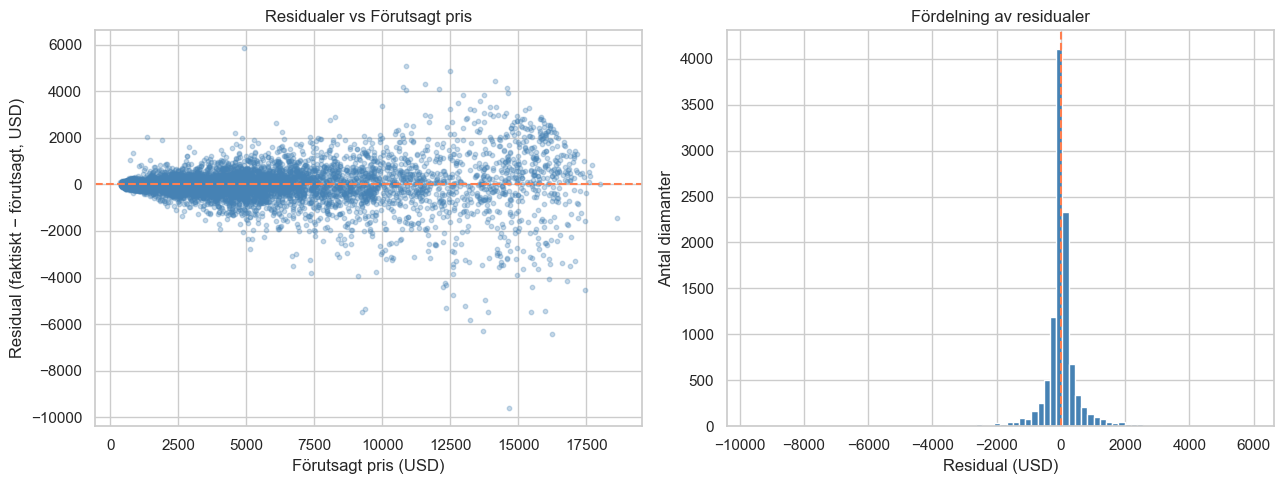


Residual-statistik:
   Medelvärde      : $-7  (≈0 = ingen systematisk bias)
   Median          : $-12
   Standardavvikelse: $641
   Max (största underskattning): $5,845
   Min (största överskattning) : $-9,614


In [8]:
# ── Residualer ─────────────────────────────────────────────────────────────────
residuals = np.asarray(y_test) - y_pred_best

# ── Två-panelers plot: residualer + histogram ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Vänster: residualer vs förutsagt pris
axes[0].scatter(y_pred_best, residuals, alpha=0.3, s=10, color="steelblue")
axes[0].axhline(0, color="coral", linestyle="--", lw=1.5)
axes[0].set_title("Residualer vs Förutsagt pris")
axes[0].set_xlabel("Förutsagt pris (USD)")
axes[0].set_ylabel("Residual (faktiskt − förutsagt, USD)")

# Höger: residualernas fördelning
axes[1].hist(residuals, bins=80, color="steelblue", edgecolor="white")
axes[1].axvline(0, color="coral", linestyle="--", lw=1.5)
axes[1].set_title("Fördelning av residualer")
axes[1].set_xlabel("Residual (USD)")
axes[1].set_ylabel("Antal diamanter")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}knn_reg_02_residualer.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Sammanfattande statistik ──────────────────────────────────────────────────
print(f"\nResidual-statistik:")
print(f"   Medelvärde      : ${residuals.mean():,.0f}  (≈0 = ingen systematisk bias)")
print(f"   Median          : ${np.median(residuals):,.0f}")
print(f"   Standardavvikelse: ${residuals.std():,.0f}")
print(f"   Max (största underskattning): ${residuals.max():,.0f}")
print(f"   Min (största överskattning) : ${residuals.min():,.0f}")

### Vad ser vi? — Residualanalys

**Residual-statistik:**
- **Medelvärde: −$7** — i princip noll. Modellen har ingen systematisk bias
  (varken under- eller överskattar genomsnittligt)
- **Median: −$12** — också nära noll. Bekräftar avsaknad av bias
- **Standardavvikelse: $641** — typisk avvikelse från sann pris
  (samma som RMSE — väntat eftersom medel ≈ 0)
- **Max underskattning: +$5,845** — modellen missade en dyr diamant
  som låg ~$5,800 högre än förutsägelsen
- **Max överskattning: −$9,614** — största enskilda felet,
  modellen förutspådde ~$9,600 för högt

**Residualer vs Förutsagt pris (vänster plot):**
- **Klassisk "trumpetform" (heteroscedasticitet):** spridningen växer
  med priset. Vid $0–$5,000 är felen oftast inom ±$1,000. Vid $15,000+
  kan felen vara ±$5,000 eller mer.
- **Punktmolnet är centrerat runt 0** vid alla prisnivåer — modellen
  är opartisk på medelvärdesnivå
- **Asymmetri:** några stora negativa residualer ($-9,614!) kan ses
  i mellanintervallet ($5,000–$15,000). Det är diamanter där modellen
  trodde att priset var mycket högre än det faktiskt var

**Fördelning av residualer (höger plot):**
- **Skarp topp vid 0** — de allra flesta diamanter förutspås nästan
  perfekt (residual nära 0)
- **Symmetrisk klockform** — påminner om en normalfördelning, vilket
  är ett **gott tecken**: modellen gör inte systematiska fel åt något håll
- **Tunga svansar:** några extremfall i båda riktningarna ($-9,614 och $5,845)

**Vad detta betyder:**
- Modellen är **välkalibrerad i genomsnitt** men har växande
  osäkerhet vid höga priser. Detta är förväntat och inte ett tecken
  på dålig modell — det är en konsekvens av:
  - Färre dyra diamanter i datasetet (mindre data att lära från)
  - KNN:s inbyggda begränsning (medelvärdesberäkning kan inte överstiga
    grannarnas högsta pris)
- För affärsanvändning skulle vi kunna **rapportera ett konfidensintervall**
  som växer med priset istället för en enskild punktförutsägelse

**Slutgiltig jämförelse — KNN Regressor:**

| Mått | Baseline (k=5) | Optimerad |
|---|---|---|
| RMSE | $703 | $641 |
| MAE | $373 | $326 |
| R² | 0.968 | 0.974 |

Optimeringen gav 9% lägre RMSE, 13% lägre MAE och +0.6 procentenheter
i R² — meningsfulla förbättringar.

## 8. Sammanfattning — KNN Regressor

Resultat och slutsatser från detta experiment.

In [9]:
# ── Sammanfattning ─────────────────────────────────────────────────────────────
print("=" * 55)
print("   Sammanfattning — KNN Regressor")
print("=" * 55)

print(f"""
MODELL: K-Nearest Neighbors Regressor

EXPERIMENT 1 — Baseline (k=5, uniform, euclidean):
   RMSE : ${rmse_5:,.0f}
   MAE  : ${mae_5:,.0f}
   R²   : {r2_5:.4f}

EXPERIMENT 2 — Manuellt k-svep (k=1 till k=25):
   Bästa k : {best_k_manual}
   R²      : {best_r2_manual:.4f}
   RMSE    : ${best_rmse_manual:,.0f}

EXPERIMENT 3 — GridSearchCV (k, weights, metric):
   Bästa k       : {grid.best_params_['n_neighbors']}
   Bästa weights : {grid.best_params_['weights']}
   Bästa metric  : {grid.best_params_['metric']}
   CV-R²         : {grid.best_score_:.4f}
   Test-R²       : {r2_best:.4f}
   Test-RMSE     : ${rmse_best:,.0f}
   Test-MAE      : ${mae_best:,.0f}

SLUTSATSER:
   1. KNN Regressor förklarar ~97% av prisvariationen — mycket starkt
   2. Manhattan + distance-vikter vinner igen — samma som klassificeraren
   3. RMSE >> MAE → enstaka stora fel, främst på dyra diamanter
   4. KNN underskattar systematiskt de dyraste diamanterna pga
      medelvärdesberäkning över grannar
   5. Optimering gav meningsfull förbättring i RMSE och MAE

NÄSTA STEG:
   Notebook 05: PCA + UMAP — kan dimensionsreduktion förbättra
   modellerna eller åtminstone hjälpa oss visualisera klasserna?
""")
print("=" * 55)

   Sammanfattning — KNN Regressor

MODELL: K-Nearest Neighbors Regressor

EXPERIMENT 1 — Baseline (k=5, uniform, euclidean):
   RMSE : $703
   MAE  : $373
   R²   : 0.9682

EXPERIMENT 2 — Manuellt k-svep (k=1 till k=25):
   Bästa k : 6
   R²      : 0.9683
   RMSE    : $701

EXPERIMENT 3 — GridSearchCV (k, weights, metric):
   Bästa k       : 9
   Bästa weights : distance
   Bästa metric  : manhattan
   CV-R²         : 0.9733
   Test-R²       : 0.9736
   Test-RMSE     : $641
   Test-MAE      : $326

SLUTSATSER:
   1. KNN Regressor förklarar ~97% av prisvariationen — mycket starkt
   2. Manhattan + distance-vikter vinner igen — samma som klassificeraren
   3. RMSE >> MAE → enstaka stora fel, främst på dyra diamanter
   4. KNN underskattar systematiskt de dyraste diamanterna pga
      medelvärdesberäkning över grannar
   5. Optimering gav meningsfull förbättring i RMSE och MAE

NÄSTA STEG:
   Notebook 05: PCA + UMAP — kan dimensionsreduktion förbättra
   modellerna eller åtminstone hjälpa